/var/folders/dk/53qw_7r15q18hjcxfln983jh0000gn/T/ipykernel_7418/167887626.py:317: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.96])


Dashboard saved to: heart_failure_dashboard.png


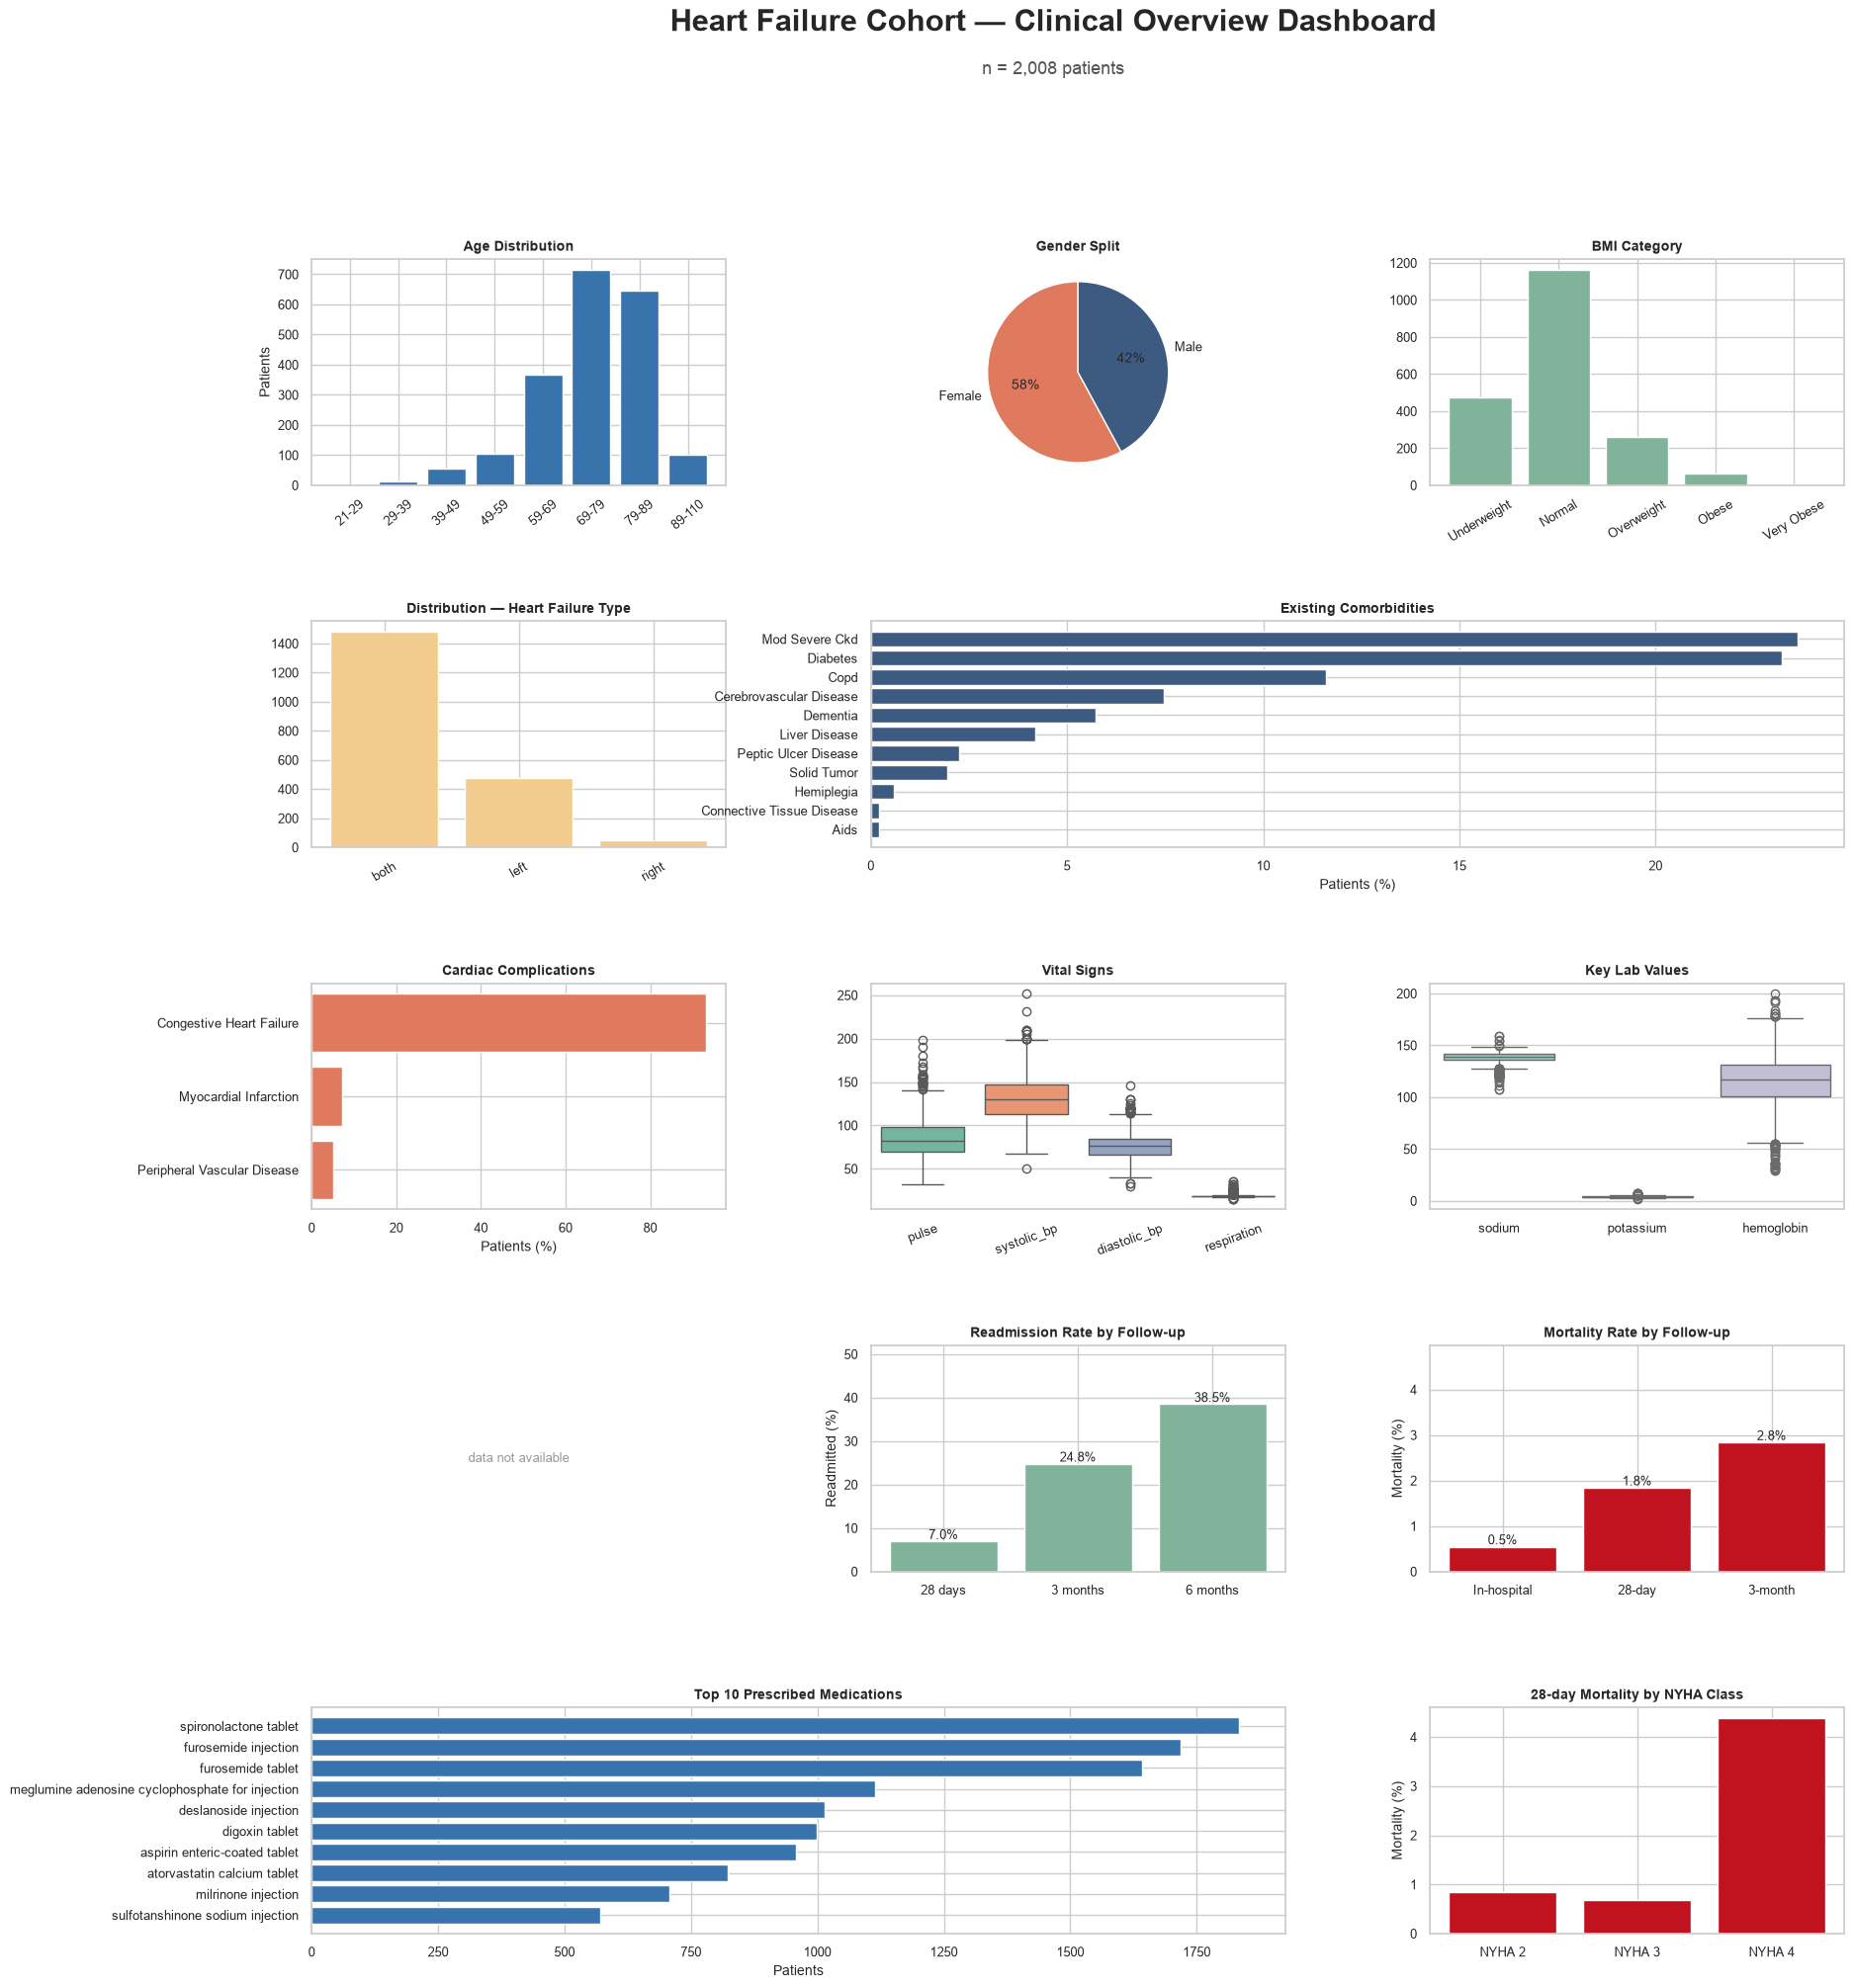

In [1]:
"""
Heart Failure Cohort — Clinical Overview Dashboard
====================================================
Builds a single-page, multi-panel dashboard summarizing the key
findings from the descriptive analysis notebook (demographics,
comorbidities, vitals/labs, length of stay, readmission, mortality,
and medications).

Usage
-----
    from heart_failure_dashboard import build_dashboard

    # df = your cleaned dataframe (e.g. hf_df from the notebook)
    build_dashboard(df)
    build_dashboard(df, save_path="dashboard.png")

Or run standalone (edit the CSV path at the bottom of the file):
    python heart_failure_dashboard.py

Design notes
------------
Every panel checks for the columns it needs and quietly turns itself
off (blank axis) if they're absent, so the dashboard degrades
gracefully on partial datasets instead of raising errors.
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

sns.set_theme(style="whitegrid", font_scale=0.85)

PALETTE = {
    "blue": "#3973AC",
    "teal": "#3D5A80",
    "green": "#81B29A",
    "orange": "#E07A5F",
    "gold": "#F2CC8F",
    "red": "#C1121F",
}


# --------------------------------------------------------------------------
# Helpers
# --------------------------------------------------------------------------

def _num(series: pd.Series) -> pd.Series:
    """Coerce a column to numeric, ignoring bad values."""
    return pd.to_numeric(series, errors="coerce")


def _pct_true(series: pd.Series) -> float:
    """Percentage of non-null values that are truthy / > 0."""
    s = _num(series).dropna()
    return float((s > 0).mean() * 100) if len(s) else np.nan


def _blank(ax, msg="data not available"):
    ax.axis("off")
    ax.text(0.5, 0.5, msg, ha="center", va="center",
            fontsize=9, color="#999999", transform=ax.transAxes)


# --------------------------------------------------------------------------
# Individual panels
# --------------------------------------------------------------------------

def _panel_age(ax, df):
    if "age_category" not in df.columns:
        return _blank(ax)
    counts = df["age_category"].dropna().astype(str).value_counts()
    try:
        order = sorted(counts.index, key=lambda x: int(x.split("-")[0].strip()))
        counts = counts.reindex(order)
    except Exception:
        pass
    ax.bar(counts.index, counts.values, color=PALETTE["blue"])
    ax.set_title("Age Distribution", fontweight="bold")
    ax.set_ylabel("Patients")
    ax.tick_params(axis="x", rotation=40)


def _panel_gender(ax, df):
    if "gender" not in df.columns:
        return _blank(ax)
    g = df["gender"].dropna().astype(str).value_counts()
    colors = [PALETTE["orange"], PALETTE["teal"], PALETTE["gold"]]
    ax.pie(g.values, labels=g.index, autopct="%1.0f%%",
           colors=colors[:len(g)], startangle=90,
           wedgeprops={"edgecolor": "white"})
    ax.set_title("Gender Split", fontweight="bold")


def _panel_bmi(ax, df):
    if "bmi" not in df.columns:
        return _blank(ax)
    bmi = _num(df["bmi"]).dropna()
    order = ["Underweight", "Normal", "Overweight", "Obese", "Very Obese"]
    cats = pd.cut(bmi, bins=[0, 18.5, 24.9, 29.9, 34.9, np.inf], labels=order)
    counts = cats.value_counts().reindex(order)
    ax.bar(counts.index, counts.values, color=PALETTE["green"])
    ax.set_title("BMI Category", fontweight="bold")
    ax.tick_params(axis="x", rotation=30)


def _panel_hf_type(ax, df):
    col = next((c for c in ["heart_failure_type",
                             "nyha_cardiac_function_classification",
                             "killip_grade"] if c in df.columns), None)
    if col is None:
        return _blank(ax)
    counts = df[col].dropna().astype(str).str.strip().value_counts()
    ax.bar(counts.index, counts.values, color=PALETTE["gold"])
    ax.set_title(f"Distribution — {col.replace('_', ' ').title()}", fontweight="bold")
    ax.tick_params(axis="x", rotation=30)


def _panel_comorbidities(ax, df):
    cols = [c for c in [
        "mod_severe_ckd", "diabetes", "copd", "cerebrovascular_disease",
        "dementia", "liver_disease", "peptic_ulcer_disease", "solid_tumor",
        "hemiplegia", "connective_tissue_disease", "aids",
    ] if c in df.columns]
    if not cols:
        return _blank(ax)
    pct = pd.Series({c: _pct_true(df[c]) for c in cols}).sort_values(ascending=False)
    labels = [c.replace("_", " ").title() for c in pct.index]
    ax.barh(labels, pct.values, color=PALETTE["teal"])
    ax.invert_yaxis()
    ax.set_xlabel("Patients (%)")
    ax.set_title("Existing Comorbidities", fontweight="bold")


def _panel_complications(ax, df):
    cols = [c for c in ["congestive_heart_failure", "myocardial_infarction",
                         "peripheral_vascular_disease"] if c in df.columns]
    if not cols:
        return _blank(ax)
    pct = pd.Series({c: _pct_true(df[c]) for c in cols}).sort_values(ascending=False)
    labels = [c.replace("_", " ").title() for c in pct.index]
    ax.barh(labels, pct.values, color=PALETTE["orange"])
    ax.invert_yaxis()
    ax.set_xlabel("Patients (%)")
    ax.set_title("Cardiac Complications", fontweight="bold")


def _panel_vitals(ax, df):
    cols = [c for c in ["pulse", "systolic_bp", "diastolic_bp", "respiration"]
            if c in df.columns]
    if not cols:
        return _blank(ax)
    vdf = df[cols].apply(_num)
    sns.boxplot(data=vdf, ax=ax, palette="Set2")
    ax.set_title("Vital Signs", fontweight="bold")
    ax.tick_params(axis="x", rotation=20)


def _panel_labs(ax, df):
    cols = [c for c in ["sodium", "potassium", "hemoglobin"] if c in df.columns]
    if not cols:
        return _blank(ax)
    ldf = df[cols].apply(_num)
    sns.boxplot(data=ldf, ax=ax, palette="Set3")
    ax.set_title("Key Lab Values", fontweight="bold")


def _panel_los(ax, df):
    col = next((c for c in ["los_days", "length_of_stay", "hospital_los"]
                if c in df.columns), None)
    if col is None:
        return _blank(ax)
    los = _num(df[col]).dropna()
    los = los[los >= 0]
    if los.empty:
        return _blank(ax)
    ax.hist(los, bins=25, color=PALETTE["blue"], edgecolor="white")
    ax.axvline(los.median(), color=PALETTE["red"], linestyle="--",
               label=f"Median = {los.median():.0f}d")
    ax.set_title("Length of Stay", fontweight="bold")
    ax.set_xlabel("Days")
    ax.legend(fontsize=8)


def _panel_readmission(ax, df):
    mapping = {"28 days": "readmission_28d", "3 months": "readmission_3mo",
               "6 months": "readmission_6mo"}
    labels, values = [], []
    for label, col in mapping.items():
        if col in df.columns:
            labels.append(label)
            values.append(_pct_true(df[col]))
    if not labels:
        return _blank(ax)
    bars = ax.bar(labels, values, color=PALETTE["green"])
    for b, v in zip(bars, values):
        ax.text(b.get_x() + b.get_width() / 2, v + 0.5, f"{v:.1f}%",
                ha="center", fontsize=9)
    ax.set_title("Readmission Rate by Follow-up", fontweight="bold")
    ax.set_ylabel("Readmitted (%)")
    ax.set_ylim(0, max(values) * 1.3 + 2)


def _panel_mortality(ax, df):
    labels, values = [], []
    if "in_hosp_outcome" in df.columns:
        vals = df["in_hosp_outcome"].astype(str).str.strip().str.lower()
        values.append(float(vals.isin(["dead", "death", "died"]).mean() * 100))
        labels.append("In-hospital")
    if "mortality_28d" in df.columns:
        values.append(_pct_true(df["mortality_28d"]))
        labels.append("28-day")
    if "mortality_3mo" in df.columns:
        values.append(_pct_true(df["mortality_3mo"]))
        labels.append("3-month")
    if not labels:
        return _blank(ax)
    bars = ax.bar(labels, values, color=PALETTE["red"])
    for b, v in zip(bars, values):
        ax.text(b.get_x() + b.get_width() / 2, v + 0.05, f"{v:.1f}%",
                ha="center", fontsize=9)
    ax.set_title("Mortality Rate by Follow-up", fontweight="bold")
    ax.set_ylabel("Mortality (%)")
    ax.set_ylim(0, max(values) * 1.4 + 1)


def _panel_medications(ax, df):
    if "drugs_list" not in df.columns:
        return _blank(ax)
    meds = (df["drugs_list"].dropna().astype(str).str.split(",")
            .explode().str.strip().str.lower())
    meds = meds[meds != ""]
    if meds.empty:
        return _blank(ax)
    top = meds.value_counts().head(10)
    ax.barh(top.index, top.values, color=PALETTE["blue"])
    ax.invert_yaxis()
    ax.set_xlabel("Patients")
    ax.set_title("Top 10 Prescribed Medications", fontweight="bold")


def _panel_nyha_mortality(ax, df):
    if "nyha_cardiac_function_classification" not in df.columns or \
       "mortality_28d" not in df.columns:
        return _blank(ax)
    sdf = pd.DataFrame({
        "nyha": _num(df["nyha_cardiac_function_classification"]),
        "died": _num(df["mortality_28d"]).fillna(0),
    }).dropna(subset=["nyha"])
    if sdf.empty:
        return _blank(ax)
    summary = sdf.groupby("nyha")["died"].mean() * 100
    labels = [f"NYHA {int(i)}" for i in summary.index]
    ax.bar(labels, summary.values, color=PALETTE["red"])
    ax.set_title("28-day Mortality by NYHA Class", fontweight="bold")
    ax.set_ylabel("Mortality (%)")


# --------------------------------------------------------------------------
# Main entry point
# --------------------------------------------------------------------------

def build_dashboard(df: pd.DataFrame, save_path: str | None = None, dpi: int = 150):
    """
    Build a one-page clinical dashboard from a cleaned heart-failure
    dataframe.

    Parameters
    ----------
    df : pd.DataFrame
        The cleaned patient-level dataframe (e.g. `hf_df` from the
        analysis notebook).
    save_path : str, optional
        If given, the figure is saved to this path (PNG/PDF/etc.).
    dpi : int
        Resolution used when saving.

    Returns
    -------
    matplotlib.figure.Figure
    """
    fig = plt.figure(figsize=(20, 22))
    gs = gridspec.GridSpec(5, 3, figure=fig, hspace=0.6, wspace=0.35)

    fig.suptitle("Heart Failure Cohort — Clinical Overview Dashboard",
                 fontsize=22, fontweight="bold", y=0.995)
    fig.text(0.5, 0.965, f"n = {len(df):,} patients",
              ha="center", fontsize=13, color="#555555")

    panels = [
        (0, 0, _panel_age),
        (0, 1, _panel_gender),
        (0, 2, _panel_bmi),
        (1, 0, _panel_hf_type),
    ]
    for row, col, fn in panels:
        fn(fig.add_subplot(gs[row, col]), df)

    # Wide comorbidity panel spans two columns
    _panel_comorbidities(fig.add_subplot(gs[1, 1:]), df)

    for row, col, fn in [
        (2, 0, _panel_complications),
        (2, 1, _panel_vitals),
        (2, 2, _panel_labs),
        (3, 0, _panel_los),
        (3, 1, _panel_readmission),
        (3, 2, _panel_mortality),
        (4, 2, _panel_nyha_mortality),
    ]:
        fn(fig.add_subplot(gs[row, col]), df)

    # Wide medications panel spans two columns
    _panel_medications(fig.add_subplot(gs[4, :2]), df)

    plt.tight_layout(rect=[0, 0, 1, 0.96])

    if save_path:
        fig.savefig(save_path, dpi=dpi, bbox_inches="tight")
        print(f"Dashboard saved to: {save_path}")

    plt.show()
    return fig


if __name__ == "__main__":
    # Standalone usage — point this at your cleaned CSV file.
    CSV_PATH = "cleaned_files/heart_failure_merged.csv"
    hf_df = pd.read_csv(CSV_PATH)
    build_dashboard(hf_df, save_path="heart_failure_dashboard.png")